In [11]:
%load_ext autoreload
%autoreload 2
from data_handling import *
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
# from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too high --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','TKG3'],
                'gulkana':['AU','B','D'] # 'B','MG1',
                }

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# for fn in os.listdir(base_fp):
#     if '.nc' in fn:
#         ds = xr.open_dataset(base_fp + fn)
#         glacier = ds.attrs['glacier']
#         site = ds.attrs['site']
#         if site != 'KQU':
#             mb = MassBalance(glacier, site)
#             mb.get_model_mb(ds)
#             mb.plot_mb()
#             print(mb.mae())

In [2]:
# glacier = 'kennicott'
# site = 'GTL'
# snowmelt_class = SnowMelt(glacier, site)
# dem_class = DEM(glacier)
# albedo = Albedo(glacier, site)
# dem_class.reproject_to(albedo.ds)
# albedo.plot_map_snowline('2021-07-01', snowmelt_class, dem_class, snowline_var='snowline_elev_m', plot_sites=['GTL','GTH'])

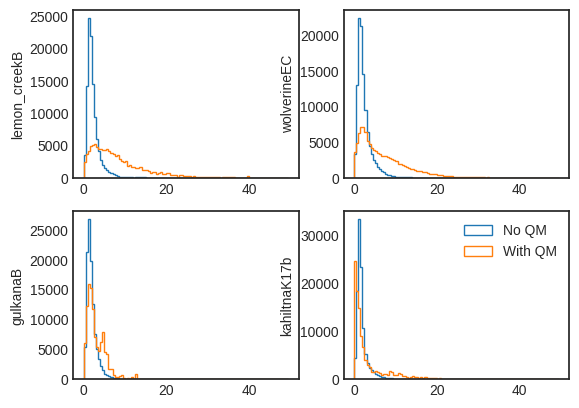

In [13]:
glaciersites = ['lemon_creekB','wolverineEC','gulkanaB','kahiltnaK17b']
fig, axes = plt.subplots(2,2)
bins = np.arange(0, 50, 0.5)
axes = axes.flatten()
for gs, ax in zip(glaciersites, axes):
    noqm = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/{gs}_2026_05_04_drydust50x_ksp0.8_0_climate.nc')
    wqm = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/{gs}_2026_05_04_drydust50x_ksp0.8_windqm_1_climate.nc')
    ax.hist(noqm.wind, bins=bins, histtype='step', label='No QM')
    ax.hist(wqm.wind, bins=bins, histtype='step', label='With QM')
    ax.set_ylabel(gs)
ax.legend()
plt.show()

In [16]:
fn = 'ddf/{g}{s}_2026_05_04_test_0.nc'
all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
all_best = {}
for glacier in site_dict:
    best_dict[glacier] = {}
    all_best[glacier] = {}
    for site in site_dict[glacier]:
        fn_ds = base_fp + fn.format(g=glacier, s=site)
        ds = xr.open_dataset(fn_ds)

        albedo_data = Albedo(glacier, site, use='all')
        albedo_data.get_model_albedo(ds) # , snow_only=True
        mb_data = MassBalance(glacier, site, use='benchmark')
        mb_data.get_model_mb(ds)

        if len(mb_data.mod) < 2:
            print('insufficient data')
            continue
        elif mb_data.dataset == 'seasonal':
            me_summer, me_winter = mb_data.bias(True)
            if np.abs(me_summer) > 1 or np.abs(me_winter) > 1:
                print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
                print('Summer mass balance bias:',me_summer)
                print('Winter mass balance bias:',me_winter)
                print('Albedo bias:',albedo_data.bias())
                print()
                for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                    all_mod_albedo.append(mod)
                    all_meas_albedo.append(meas)
                    all_time_albedo.append(t)
                # mb_data.plot_mb()
            else:
                print(glacier, site, 'is good')
                
        else:
            if np.abs(mb_data.mae()) > 1:
                print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
                print('Annual mass balance bias:',mb_data.mae())
                print('Albedo bias:',albedo_data.bias())
                print()
                for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                    all_mod_albedo.append(mod)
                    all_meas_albedo.append(meas)
                    all_time_albedo.append(t)
                # mb_data.plot_mb()
            else:
                print(glacier, site, 'is good')
                
               
        # plot
        # mb_data.plot_mb()
        # albedo_data.plot_timeseries()
        # albedo_data.plot_1to1()
        # albedo_data.plot_map('2019-08-20',full=True, savefig=True)

        

wolverine N is good
wolverine B is good
wolverine EC has biased mass balance using kp= 1.981469475081177
Summer mass balance bias: -2.0493819675685647
Winter mass balance bias: -2.390028567890116
Albedo bias: -0.05788142378060642

kahiltna K53 is good
kahiltna K17b is good
kennicott GTL has biased mass balance using kp= 1.0094549347163355
Summer mass balance bias: 2.631506274986227
Winter mass balance bias: 0.6592395623215543
Albedo bias: 0.14445303517566266

kennicott GTH has biased mass balance using kp= 1.6634793010179634
Summer mass balance bias: -0.8302256693721793
Winter mass balance bias: -1.1275727636881723
Albedo bias: -0.03660044198844415

kennicott KC31 has biased mass balance using kp= 1.130154191842188
Summer mass balance bias: 2.6960374089888632
Winter mass balance bias: 0.9620893902882122
Albedo bias: 0.23531740233536944

lemon_creek B has biased mass balance using kp= 1.4230809067903878
Summer mass balance bias: 1.8067576548727757
Winter mass balance bias: -0.6464742484

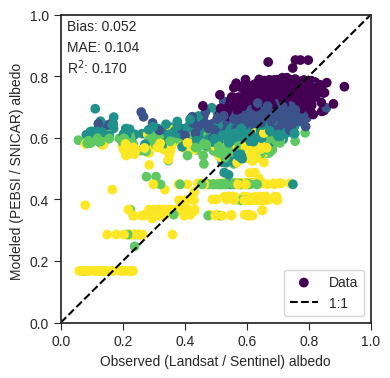

In [17]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(mod - meas)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
# ax.set_title('Albedo modeled at Gulkana Glacier')
ax.set_ylabel('Modeled (PEBSI / SNICAR) albedo ')
ax.set_xlabel('Observed (Landsat / Sentinel) albedo')
plt.savefig('/trace/group/rounce/cvwilson/figs/ddf/bad_sites.png', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1226931/1289322558.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


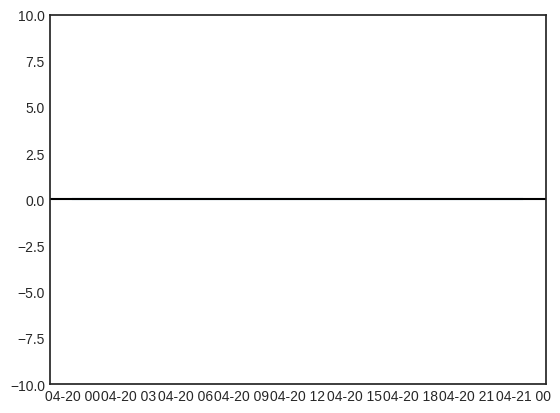

<xarray.DataArray 'airtemp' ()> Size: 8B
array(0.)
Attributes:
    units:    C


In [17]:
glacier, site = 'wolverine','EC'
fn = 'ddf/{g}{s}_2026_05_05_test_0.nc'
# fn.format(g=glacier, s=site)
ds_bad = xr.open_dataset(base_fp + 'ddf/test_simulation0.nc').sel(time=slice('2013-04-20','2013-04-21'))
ds_good = xr.open_dataset(base_fp + f'ddf/{glacier}{site}_2026_04_15_MO_0.nc').sel(time=slice('2013-04-20','2013-04-21'))
plt.plot(ds_bad.time, ds_bad.airtemp - ds_good.airtemp)
plt.ylim(-10, 10)
plt.axhline(0, c='k')
plt.legend()
plt.show()
print((ds_bad.airtemp - ds_good.airtemp).mean())

In [34]:
-1.417 / -0.0065

218.00000000000003

In [ ]:
#######################################################################################